# GARCH-Adjusted Volatility Compression + Timed Breakout Backtest

This notebook implements a **GARCH-adjusted compression + breakout** execution strategy with an added **intraminute timing layer**.

The main revision is on the **sell side**:
- every stock still sells every minute
- no stock is forced into TWAP-only mode
- when an **upward breakout** occurs during a compressed minute, the sell side uses extra microstructure signals to choose a better selling time within the remainder of the minute

The added timing signals are:
- **top-of-book imbalance**
- **microprice deviation from mid**
- **short-horizon momentum**
- **spread penalty**

These signals are used only as a **timing refinement after the breakout event**, so the strategy remains distinct from a continuous always-on score strategy.


## 1. Imports

The next cell imports the libraries used in the notebook.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 2. User inputs

Change `INPUT_PATH` to your CSV file or to a folder containing multiple stock CSV files.

Use a **relative** output folder such as `results` so the notebook writes to a normal writable directory.

The GARCH-related parameters below control the conditional volatility forecast used in:
1. the compression rule, and
2. the adaptive breakout buffer.


## 3. Timed sell-side refinement

All stocks use the same structure:
- detect a **compressed minute**
- wait for an **upward breakout**
- then choose the sell execution time inside the rest of the minute using a **timing score**

The timing score rewards:
- higher current bid price
- stronger bid-side imbalance
- microprice above the mid
- positive short-term momentum

and penalizes:
- wide spreads

This keeps the strategy event-driven while making the delay decision more selective.


## 3. Helper functions

Each function below includes comments explaining what the function does, where it is used, and what its main output means.

This notebook uses a lightweight self-contained GARCH(1,1)-style recursion, so it does not require an external `arch` package.


In [2]:

@dataclass
class StockResult:
    # Container for the main outputs of one stock backtest.
    # Usage: returned by run_backtest_for_file() so later cells can access
    # the execution log, summary table, and aggregate metrics cleanly.
    stock: str
    execution_log: pd.DataFrame
    summary: pd.DataFrame
    aggregate_metrics: Dict[str, float]


def infer_stock_name(path: Path) -> str:
    # Extract a cleaner stock symbol from a file name.
    # Usage: GOOG_5levels_train.csv -> GOOG
    name = path.stem
    for suffix in ["_5levels_train", "_5levels_test", "_train", "_test"]:
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return name


def get_stock_side_rule(stock: str) -> Dict[str, float]:
    # Return the stock-specific side rule configuration.
    # Usage: called inside the simulation so the sell-side timing score can
    # be adjusted by stock without disabling the strategy.
    return STOCK_SIDE_RULES.get(
        stock,
        {"sell_mode": "timed_delay_on_up_breakout", "sell_strength": 1.0},
    )


REQUIRED_COLS = [
    "Time",
    "BidPrice_1",
    "AskPrice_1",
    "BidSize_1",
    "AskSize_1",
    "Spread",
    "MidPrice",
]


def estimate_tick_size(df: pd.DataFrame) -> float:
    # Estimate the minimum price increment from the order book columns.
    # Usage: breakout buffers are partly specified in ticks, so this function
    # converts the tick-based buffer into an actual price increment.
    candidates: List[float] = []
    for col in ["BidPrice_1", "AskPrice_1", "BidPrice_2", "AskPrice_2"]:
        if col in df.columns:
            diffs = df[col].diff().abs()
            diffs = diffs[(diffs > 0) & np.isfinite(diffs)]
            if not diffs.empty:
                candidates.append(float(diffs.quantile(0.05)))

    if candidates:
        positive_candidates = [x for x in candidates if x > 0]
        if positive_candidates:
            tick = min(positive_candidates)
            return max(tick, 1e-4)
    return 0.01


def load_and_prepare_csv(path: Path) -> pd.DataFrame:
    # Read one CSV file and create the basic fields used everywhere else.
    # Usage: this is the first function called inside run_backtest_for_file().
    # It validates required columns, parses timestamps, sorts the data,
    # creates the minute label, and stores the estimated tick size.
    df = pd.read_csv(path)

    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {missing}")

    df["timestamp"] = pd.to_datetime("1900-01-01 " + df["Time"].astype(str), errors="coerce")
    df = df.dropna(subset=["timestamp"]).copy()
    df = df.sort_values("timestamp").reset_index(drop=True)
    df["Minute"] = df["timestamp"].dt.floor("min")

    tick = estimate_tick_size(df)
    df["tick_size"] = tick
    df["spread_ticks"] = np.maximum(df["Spread"] / tick, 0.0)
    return df


def compute_garch_variance(log_ret: pd.Series) -> pd.Series:
    # Build a lightweight GARCH(1,1)-style conditional variance series.
    # Usage: called inside compute_features() to estimate the current volatility regime.
    r = log_ret.fillna(0.0).astype(float)
    long_run_var = (
        r.rolling(LONG_RUN_VAR_WINDOW, min_periods=max(50, LONG_RUN_VAR_WINDOW // 5)).var()
        .shift(1)
    )
    fallback_var = float(np.nanvar(r.values))
    if not np.isfinite(fallback_var) or fallback_var <= 0:
        fallback_var = MIN_VAR
    long_run_var = long_run_var.fillna(fallback_var).clip(lower=MIN_VAR)

    alpha = GARCH_ALPHA
    beta = GARCH_BETA
    omega = (1.0 - alpha - beta) * long_run_var

    sigma2 = np.zeros(len(r), dtype=float)
    sigma2[0] = max(float(long_run_var.iloc[0]), MIN_VAR)

    r_values = r.values
    omega_values = omega.values

    for t in range(1, len(r)):
        sigma2[t] = omega_values[t] + alpha * (r_values[t - 1] ** 2) + beta * sigma2[t - 1]
        sigma2[t] = max(sigma2[t], MIN_VAR)

    return pd.Series(sigma2, index=r.index, name="garch_var")


def safe_zscore(series: pd.Series) -> pd.Series:
    # Standardize a series safely.
    # Usage: used inside the intraminute timing score so components are on
    # roughly comparable scales even when a minute has very few rows.
    s = pd.Series(series, index=series.index, dtype=float)
    std = float(s.std(ddof=0))
    if not np.isfinite(std) or std < 1e-12:
        return pd.Series(np.zeros(len(s), dtype=float), index=s.index)
    mean = float(s.mean())
    return (s - mean) / std


def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    # Build the GARCH-adjusted compression, breakout, and timing features.
    # Usage: called after load_and_prepare_csv() and before simulation.
    out = df.copy()

    mid = out["MidPrice"].astype(float)
    log_mid = np.log(mid.replace(0, np.nan)).ffill().bfill()
    log_ret = log_mid.diff().fillna(0.0)

    out["log_ret"] = log_ret
    out["garch_var"] = compute_garch_variance(log_ret)
    out["garch_sigma"] = np.sqrt(out["garch_var"]).clip(lower=np.sqrt(MIN_VAR))

    min_periods_short = max(10, SHORT_WINDOW // 4)

    out["short_realized_vol"] = log_ret.rolling(SHORT_WINDOW, min_periods=min_periods_short).std()
    out["short_range_rel"] = (
        mid.rolling(SHORT_WINDOW, min_periods=min_periods_short).max()
        - mid.rolling(SHORT_WINDOW, min_periods=min_periods_short).min()
    ) / mid.replace(0, np.nan)

    # Scale recent range by a volatility forecast over roughly the same horizon.
    out["garch_horizon_vol"] = out["garch_sigma"] * np.sqrt(SHORT_WINDOW)

    out["vol_ratio_to_garch"] = out["short_realized_vol"] / out["garch_sigma"].replace(0, np.nan)
    out["range_ratio_to_garch"] = out["short_range_rel"] / out["garch_horizon_vol"].replace(0, np.nan)

    vol_ratio_hist = out["vol_ratio_to_garch"].shift(1)
    range_ratio_hist = out["range_ratio_to_garch"].shift(1)

    min_periods_hist = max(50, HISTORY_WINDOW // 5)
    out["vol_ratio_threshold"] = (
        vol_ratio_hist.rolling(HISTORY_WINDOW, min_periods=min_periods_hist).quantile(COMPRESSION_Q)
    )
    out["range_ratio_threshold"] = (
        range_ratio_hist.rolling(HISTORY_WINDOW, min_periods=min_periods_hist).quantile(COMPRESSION_Q)
    )

    global_vol_q = float(out["vol_ratio_to_garch"].quantile(COMPRESSION_Q))
    global_range_q = float(out["range_ratio_to_garch"].quantile(COMPRESSION_Q))

    if not np.isfinite(global_vol_q):
        global_vol_q = 1.0
    if not np.isfinite(global_range_q):
        global_range_q = 1.0

    out["vol_ratio_threshold"] = out["vol_ratio_threshold"].fillna(global_vol_q)
    out["range_ratio_threshold"] = out["range_ratio_threshold"].fillna(global_range_q)

    out["is_compressed"] = (
    (out["vol_ratio_to_garch"].shift(1) <= out["vol_ratio_threshold"])
    | (out["range_ratio_to_garch"].shift(1) <= out["range_ratio_threshold"])
    )

    out["prior_band_high"] = mid.shift(1).rolling(SHORT_WINDOW, min_periods=min_periods_short).max()
    out["prior_band_low"] = mid.shift(1).rolling(SHORT_WINDOW, min_periods=min_periods_short).min()

    tick = float(out["tick_size"].iloc[0])
    vol_buffer = BREAKOUT_VOL_MULT * out["garch_sigma"].shift(1).fillna(out["garch_sigma"].median()) * mid
    tick_buffer = BREAKOUT_BASE_TICKS * tick
    out["breakout_buffer"] = np.maximum(tick_buffer, vol_buffer)

    out["breakout_up"] = out["MidPrice"] > (out["prior_band_high"] + out["breakout_buffer"])
    out["breakout_down"] = out["MidPrice"] < (out["prior_band_low"] - out["breakout_buffer"])

    # Added timing signals.
    denom = (out["BidSize_1"].astype(float) + out["AskSize_1"].astype(float)).replace(0, np.nan)
    out["imbalance_1"] = (
        (out["BidSize_1"].astype(float) - out["AskSize_1"].astype(float)) / denom
    ).fillna(0.0)
    out["imbalance_smooth"] = out["imbalance_1"].rolling(IMBALANCE_SMOOTH, min_periods=1).mean()

    out["microprice"] = (
        out["AskPrice_1"].astype(float) * out["BidSize_1"].astype(float)
        + out["BidPrice_1"].astype(float) * out["AskSize_1"].astype(float)
    ) / denom
    out["microprice"] = out["microprice"].fillna(out["MidPrice"].astype(float))
    out["micro_dev_ticks"] = (out["microprice"] - out["MidPrice"].astype(float)) / tick

    out["momentum_ticks"] = (
        out["MidPrice"].astype(float).diff(MOMENTUM_WINDOW).fillna(0.0) / tick
    )

    return out


def find_first_breakout_direction(group: pd.DataFrame) -> str | None:
    # Find the first breakout event inside one minute.
    up_positions = np.flatnonzero(group["breakout_up"].fillna(False).to_numpy())
    down_positions = np.flatnonzero(group["breakout_down"].fillna(False).to_numpy())

    if len(up_positions) and len(down_positions):
        return "up" if up_positions[0] <= down_positions[0] else "down"
    if len(up_positions):
        return "up"
    if len(down_positions):
        return "down"
    return None


def choose_best_sell_row_after_up_breakout(group: pd.DataFrame, start_pos: int, stock: str) -> pd.Series:
    # Choose the sell execution row after an upward breakout using extra timing signals.
    # Usage: called only on the sell side after the event trigger has already happened.
    # The row is selected from the breakout row to the end of the minute.
    candidates = group.iloc[start_pos:].copy()
    if candidates.empty:
        return group.iloc[-1]

    tick = float(group["tick_size"].iloc[0])
    strength = float(get_stock_side_rule(stock).get("sell_strength", 1.0))

    # Filter out the widest-spread candidate rows if possible.
    spread_cap = float(candidates["spread_ticks"].quantile(SELL_SPREAD_FILTER_Q))
    filtered = candidates[candidates["spread_ticks"] <= spread_cap].copy()
    if filtered.empty:
        filtered = candidates.copy()

    bid_from_breakout_ticks = (
        filtered["BidPrice_1"].astype(float) - float(group.iloc[start_pos]["BidPrice_1"])
    ) / max(tick, 1e-8)

    score = (
        SELL_W_BID * safe_zscore(bid_from_breakout_ticks)
        + strength * SELL_W_IMB * safe_zscore(filtered["imbalance_smooth"])
        + strength * SELL_W_MICRO * safe_zscore(filtered["micro_dev_ticks"])
        + strength * SELL_W_MOM * safe_zscore(filtered["momentum_ticks"])
        - SELL_W_SPREAD * safe_zscore(filtered["spread_ticks"])
    )

    best_idx = score.idxmax()
    return group.loc[best_idx]


def select_execution_row(group: pd.DataFrame, side: str, stock: str) -> Tuple[pd.Series, str]:
    # Choose the execution row for one minute and one side.
    # Usage: called once per minute inside simulate_side().
    first_row = group.iloc[0]
    last_row = group.iloc[-1]

    compressed = bool(first_row.get("is_compressed", False))
    if not compressed:
        return first_row, "no_compression_first_row"

    up_positions = np.flatnonzero(group["breakout_up"].fillna(False).to_numpy())
    down_positions = np.flatnonzero(group["breakout_down"].fillna(False).to_numpy())

    first_up_pos = int(up_positions[0]) if len(up_positions) else None
    first_down_pos = int(down_positions[0]) if len(down_positions) else None
    event = find_first_breakout_direction(group)

    if side == "BUY":
        if event is None:
            return first_row, "compressed_no_breakout_fallback_twap"
        if event == "up":
            return group.iloc[first_up_pos], "compressed_up_breakout_early_buy"
        return last_row, "compressed_down_breakout_delay_buy"

    if side == "SELL":
        sell_mode = str(get_stock_side_rule(stock).get("sell_mode", "timed_delay_on_up_breakout"))

        if sell_mode != "timed_delay_on_up_breakout":
            raise ValueError(f"Unknown sell_mode for {stock}: {sell_mode}")

        # Only upward breakout is treated as a favorable sell signal.
        # The timing inside the remaining part of the minute is refined using
        # imbalance, microprice, momentum, and spread.
        if first_up_pos is not None:
            best_row = choose_best_sell_row_after_up_breakout(group, first_up_pos, stock=stock)
            return best_row, "compressed_up_breakout_timed_delay_sell"

        return first_row, "compressed_no_breakout_fallback_twap"

    raise ValueError(f"Unknown side: {side}")


def simulate_side(df: pd.DataFrame, side: str, stock: str) -> pd.DataFrame:
    # Run the minute-by-minute execution simulation for BUY or SELL.
    # Usage: called twice inside run_backtest_for_file(), once for BUY and once for SELL.
    if side not in {"BUY", "SELL"}:
        raise ValueError("side must be BUY or SELL")

    price_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"
    minute_groups = df.groupby("Minute", sort=True)
    rows: List[Dict[str, object]] = []

    for minute, group in minute_groups:
        group = group.reset_index(drop=True)
        twap_row = group.iloc[0]
        algo_row, reason = select_execution_row(group, side=side, stock=stock)

        twap_price = float(twap_row[price_col])
        algo_price = float(algo_row[price_col])

        if side == "BUY":
            improvement = twap_price - algo_price
        else:
            improvement = algo_price - twap_price

        rows.append(
            {
                "Minute": minute,
                "Side": side,
                "TWAPTime": twap_row["timestamp"],
                "AlgoTime": algo_row["timestamp"],
                "TWAPPrice": twap_price,
                "AlgoPrice": algo_price,
                "Improvement": improvement,
                "AlgoReason": reason,
            }
        )

    return pd.DataFrame(rows)


def summarize_results(stock: str, buy_log: pd.DataFrame, sell_log: pd.DataFrame) -> StockResult:
    # Build the summary table and aggregate metrics for one stock.
    avg_twap_buy = float(buy_log["TWAPPrice"].mean())
    avg_algo_buy = float(buy_log["AlgoPrice"].mean())
    avg_buy_imp = float(buy_log["Improvement"].mean())
    buy_hit_rate = float((buy_log["Improvement"] > 0).mean())

    avg_twap_sell = float(sell_log["TWAPPrice"].mean())
    avg_algo_sell = float(sell_log["AlgoPrice"].mean())
    avg_sell_imp = float(sell_log["Improvement"].mean())
    sell_hit_rate = float((sell_log["Improvement"] > 0).mean())

    merged = buy_log[["Minute", "TWAPPrice", "AlgoPrice", "Improvement", "AlgoReason"]].rename(
        columns={
            "TWAPPrice": "TWAP_BUY_Price",
            "AlgoPrice": "Algo_BUY_Price",
            "Improvement": "BUY_Improvement",
            "AlgoReason": "AlgoReason_BUY",
        }
    ).merge(
        sell_log[["Minute", "TWAPPrice", "AlgoPrice", "Improvement", "AlgoReason"]].rename(
            columns={
                "TWAPPrice": "TWAP_SELL_Price",
                "AlgoPrice": "Algo_SELL_Price",
                "Improvement": "SELL_Improvement",
                "AlgoReason": "AlgoReason_SELL",
            }
        ),
        on="Minute",
        how="inner",
    )

    merged["Overall_Improvement"] = merged["BUY_Improvement"] + merged["SELL_Improvement"]
    overall_hit_rate = float((merged["Overall_Improvement"] > 0).mean())

    summary_rows = [
        ("Trades", float(len(merged))),
        ("Average TWAP BUY", avg_twap_buy),
        ("Average Algo BUY", avg_algo_buy),
        ("Average BUY Improvement", avg_buy_imp),
        ("BUY Hit Rate", buy_hit_rate),
        ("Average TWAP SELL", avg_twap_sell),
        ("Average Algo SELL", avg_algo_sell),
        ("Average SELL Improvement", avg_sell_imp),
        ("SELL Hit Rate", sell_hit_rate),
        ("Average Overall Improvement", float(merged["Overall_Improvement"].mean())),
        ("Overall Hit Rate", overall_hit_rate),
        ("Std Overall Improvement", float(merged["Overall_Improvement"].std(ddof=0))),
        ("Cumulative Overall Improvement", float(merged["Overall_Improvement"].sum())),
    ]

    summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
    aggregate_metrics = dict(summary_rows)

    return StockResult(
        stock=stock,
        execution_log=merged,
        summary=summary_df,
        aggregate_metrics=aggregate_metrics,
    )


def make_plots(stock: str, buy_log: pd.DataFrame, sell_log: pd.DataFrame, merged: pd.DataFrame) -> None:
    # Create diagnostic plots for one stock.
    plt.figure(figsize=(12, 5))
    plt.plot(buy_log["Minute"], buy_log["TWAPPrice"], label="TWAP BUY")
    plt.plot(buy_log["Minute"], buy_log["AlgoPrice"], label="Algo BUY")
    plt.title(f"{stock} BUY prices")
    plt.xlabel("Minute")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(sell_log["Minute"], sell_log["TWAPPrice"], label="TWAP SELL")
    plt.plot(sell_log["Minute"], sell_log["AlgoPrice"], label="Algo SELL")
    plt.title(f"{stock} SELL prices")
    plt.xlabel("Minute")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(merged["Minute"], merged["Overall_Improvement"].cumsum(), label="Cumulative Overall Improvement")
    plt.axhline(0, linewidth=1)
    plt.title(f"{stock} cumulative improvement vs TWAP")
    plt.xlabel("Minute")
    plt.ylabel("Cumulative improvement")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(merged["Overall_Improvement"], bins=40)
    plt.title(f"{stock} overall improvement distribution")
    plt.xlabel("Overall improvement")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


def run_backtest_for_file(path: Path) -> Tuple[StockResult, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Full pipeline for one stock file.
    raw = load_and_prepare_csv(path)
    feat = compute_features(raw)
    stock = infer_stock_name(path)
    buy_log = simulate_side(feat, side="BUY", stock=stock)
    sell_log = simulate_side(feat, side="SELL", stock=stock)

    result = summarize_results(stock, buy_log, sell_log)

    merged = result.execution_log.copy()
    return result, raw, feat, buy_log, sell_log, merged


## 4. Run the backtest for one stock

This cell runs the full pipeline on the file in `INPUT_PATH`.


In [3]:

# =========================
# User inputs
# =========================

# Set DATA_DIR to your project data folder.
# The notebook first tries /data, then ./data, then the current directory.
if Path("/data").exists():
    DATA_DIR = Path("/data")
elif Path("data").exists():
    DATA_DIR = Path("data")
else:
    DATA_DIR = Path(".")

INPUT_PATH = DATA_DIR / "GOOG_5levels_train.csv"
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Core rolling windows
SHORT_WINDOW = 80
HISTORY_WINDOW = 2000
COMPRESSION_Q = 0.20

# Lightweight GARCH-style parameters
GARCH_ALPHA = 0.08
GARCH_BETA = 0.90
LONG_RUN_VAR_WINDOW = 1000
MIN_VAR = 1e-12

# Breakout buffer = fixed ticks + volatility-scaled term
BREAKOUT_BASE_TICKS = 0.65
BREAKOUT_VOL_MULT = 0.45

# Additional timing signals
MOMENTUM_WINDOW = 10
IMBALANCE_SMOOTH = 10

# Sell-side timing-score weights after an upward breakout
SELL_W_BID = 1.00
SELL_W_IMB = 0.80
SELL_W_MICRO = 0.80
SELL_W_MOM = 0.35
SELL_W_SPREAD = 0.50

# Only consider rows with relatively reasonable spread after the breakout
SELL_SPREAD_FILTER_Q = 0.75

# Optional mild stock-specific strength multipliers for the sell timing score.
# All stocks still use the strategy; this only changes how strongly the extra
# timing signals affect the final ranking after an upward breakout.
STOCK_SIDE_RULES = {
    "AMZN": {"sell_mode": "timed_delay_on_up_breakout", "sell_strength": 0.85},
    "GOOG": {"sell_mode": "timed_delay_on_up_breakout", "sell_strength": 0.85},
    "INTC": {"sell_mode": "timed_delay_on_up_breakout", "sell_strength": 1.00},
    "MSFT": {"sell_mode": "timed_delay_on_up_breakout", "sell_strength": 1.00},
}

print("Using DATA_DIR:", DATA_DIR.resolve())
print("Using INPUT_PATH:", INPUT_PATH)


Using DATA_DIR: /Users/wangyiling/Desktop/ORIE5259/project/data
Using INPUT_PATH: data/GOOG_5levels_train.csv


In [4]:
# Run the backtest for one stock file.
# Re-run this cell every time you change the parameters above.

result, raw_df, feat_df, buy_log, sell_log, merged = run_backtest_for_file(INPUT_PATH)

print("Finished backtest for:", result.stock)
print("Rows in raw data:", len(raw_df))
print("Rows in feature data:", len(feat_df))
print("Minutes traded:", len(result.execution_log))


Finished backtest for: GOOG
Rows in raw data: 100048
Rows in feature data: 100048
Minutes traded: 270


## 5. Inspect the engineered features

These columns are the main diagnostic columns for checking whether the **GARCH-adjusted compression** and breakout logic behave as intended.

Focus on:
- `garch_sigma`: conditional volatility forecast
- `vol_ratio_to_garch`: realized volatility relative to predicted volatility
- `range_ratio_to_garch`: recent range relative to predicted volatility scale
- `is_compressed`: whether the prior state was compressed after volatility adjustment
- `breakout_buffer`: adaptive breakout threshold


In [5]:

feature_cols = [
    "timestamp",
    "Minute",
    "MidPrice",
    "Spread",
    "spread_ticks",
    "garch_sigma",
    "short_realized_vol",
    "short_range_rel",
    "vol_ratio_to_garch",
    "range_ratio_to_garch",
    "vol_ratio_threshold",
    "range_ratio_threshold",
    "is_compressed",
    "prior_band_high",
    "prior_band_low",
    "breakout_buffer",
    "breakout_up",
    "breakout_down",
    "imbalance_1",
    "imbalance_smooth",
    "microprice",
    "micro_dev_ticks",
    "momentum_ticks",
]

feat_df[feature_cols].head(20)


,timestamp,Minute,MidPrice,Spread,spread_ticks,garch_sigma,short_realized_vol,short_range_rel,vol_ratio_to_garch,range_ratio_to_garch,vol_ratio_threshold,range_ratio_threshold,is_compressed,prior_band_high,prior_band_low,breakout_buffer,breakout_up,breakout_down,imbalance_1,imbalance_smooth,microprice,micro_dev_ticks,momentum_ticks
0,1900-01-01 09:30:00.015,1900-01-01 09:30:00,579.815,0.83,83.0,0.000052,NaN,NaN,NaN,NaN,0.644879,0.50223,False,NaN,NaN,0.006500,False,False,0.664430,0.664430,580.090738,27.573826,0.0
1,1900-01-01 09:30:00.059,1900-01-01 09:30:00,579.815,0.83,83.0,0.000049,NaN,NaN,NaN,NaN,0.644879,0.50223,False,NaN,NaN,0.013442,False,False,0.324324,0.494377,579.949595,13.459459,0.0
2,1900-01-01 09:30:00.113,1900-01-01 09:30:00,579.815,0.83,83.0,0.000047,NaN,NaN,NaN,NaN,0.644879,0.50223,False,NaN,NaN,0.012893,False,False,0.324324,0.437693,579.949595,13.459459,0.0
3,1900-01-01 09:30:00.113,1900-01-01 09:30:00,579.815,0.83,83.0,0.000046,NaN,NaN,NaN,NaN,0.644879,0.50223,False,NaN,NaN,0.012378,False,False,0.324324,0.409351,579.949595,13.459459,0.0
4,1900-01-01 09:30:00.113,1900-01-01 09:30:00,579.815,0.83,83.0,0.000044,NaN,NaN,NaN,NaN,0.644879,0.50223,False,NaN,NaN,0.011896,False,False,0.324324,0.392345,579.949595,13.459459,0.0
5,1900-01-01 09:30:00.113,1900-01-01 09:30:00,579.815,0.83,83.0,0.000042,NaN,NaN,NaN,NaN,0.644879,0.50223,False,NaN,NaN,0.011444,False,False,0.324324,0.381009,579.949595,13.459459,0.0
6,1900-01-01 09:30:00.113,1900-01-01 09:30:00,579.815,0.83,83.0,0.000041,NaN,NaN,NaN,NaN,0.644879,0.50223,False,NaN,NaN,0.011022,False,False,-0.550388,0.247952,579.586589,-22.841085,0.0
7,1900-01-01 09:30:00.154,1900-01-01 09:30:00,579.815,0.83,83.0,0.000039,NaN,NaN,NaN,NaN,0.644879,0.50223,False,NaN,NaN,0.010628,False,False,0.126638,0.232788,579.867555,5.255459,0.0
8,1900-01-01 09:30:00.173,1900-01-01 09:30:00,579.815,0.83,83.0,0.000038,NaN,NaN,NaN,NaN,0.644879,0.50223,False,NaN,NaN,0.010260,False,False,0.126638,0.220993,579.867555,5.255459,0.0
9,1900-01-01 09:30:00.202,1900-01-01 09:30:00,579.645,0.49,49.0,0.000037,NaN,NaN,NaN,NaN,0.644879,0.50223,False,NaN,NaN,0.009915,False,False,0.675325,0.266426,579.810455,16.545455,0.0


## 6. Compression and breakout rates

This helps you see how selective the strategy is after replacing the fixed compression rule with a GARCH-adjusted one.


In [6]:
compression_rate_rows = feat_df["is_compressed"].mean()
compression_rate_minutes = feat_df.groupby("Minute")["is_compressed"].first().mean()
breakout_rate_rows = (feat_df["breakout_up"] | feat_df["breakout_down"]).mean()
breakout_rate_minutes = feat_df.groupby("Minute").apply(
    lambda x: bool(x["breakout_up"].any() or x["breakout_down"].any())
).mean()

print("Compression rate by row:", round(compression_rate_rows, 4))
print("Compression rate at minute open:", round(compression_rate_minutes, 4))
print("Breakout rate by row:", round(breakout_rate_rows, 4))
print("Breakout rate by minute:", round(breakout_rate_minutes, 4))

Compression rate by row: 0.2947
Compression rate at minute open: 0.2519
Breakout rate by row: 0.0286
Breakout rate by minute: 0.9778


## 7. Visual check of compression flags

This plot marks compressed observations on a sample of the data.

Because compression is now volatility-adjusted, the flags indicate periods where realized movement is unusually small relative to the local GARCH volatility forecast.


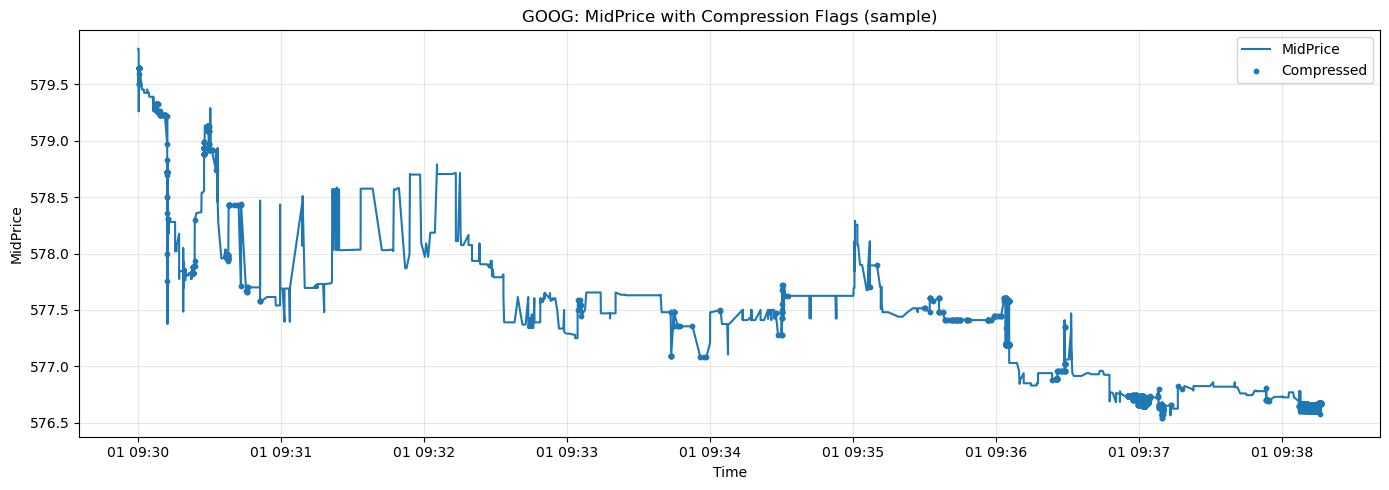

In [7]:
sample = feat_df.iloc[:5000].copy()

plt.figure(figsize=(14, 5))
plt.plot(sample["timestamp"], sample["MidPrice"], label="MidPrice")
compressed_points = sample[sample["is_compressed"].fillna(False)]
plt.scatter(compressed_points["timestamp"], compressed_points["MidPrice"], s=10, label="Compressed")
plt.title(f"{result.stock}: MidPrice with Compression Flags (sample)")
plt.xlabel("Time")
plt.ylabel("MidPrice")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Visual check of breakout flags

This plot marks upward and downward breakout observations on a sample of the data.

The breakout threshold is now adaptive: it uses both a small tick floor and a GARCH-scaled volatility buffer.


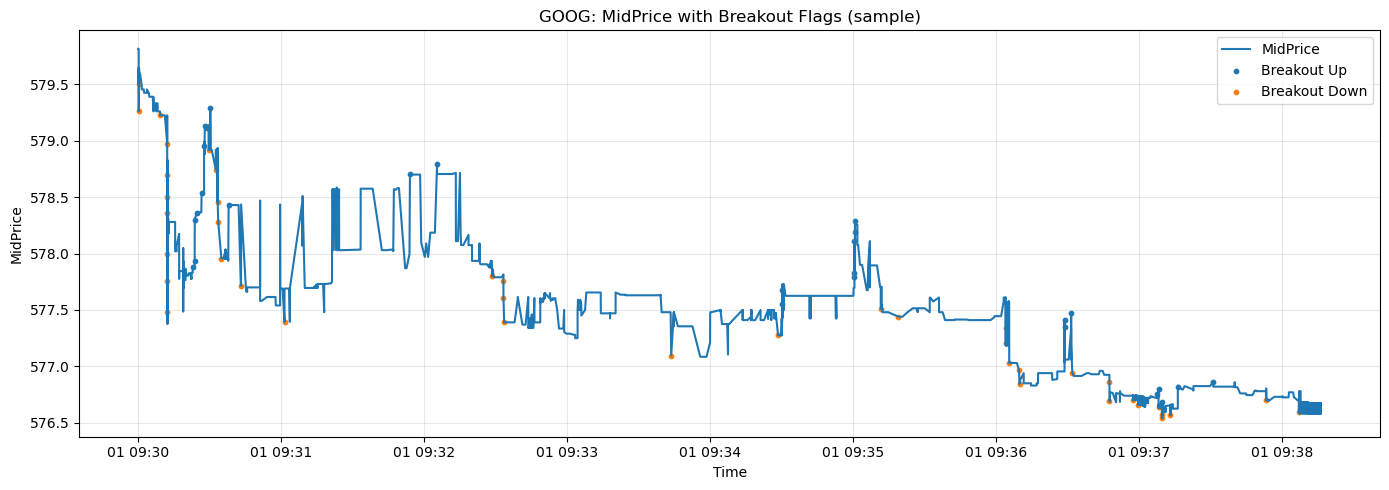

In [8]:
sample = feat_df.iloc[:5000].copy()

plt.figure(figsize=(14, 5))
plt.plot(sample["timestamp"], sample["MidPrice"], label="MidPrice")
up_points = sample[sample["breakout_up"].fillna(False)]
down_points = sample[sample["breakout_down"].fillna(False)]
plt.scatter(up_points["timestamp"], up_points["MidPrice"], s=10, label="Breakout Up")
plt.scatter(down_points["timestamp"], down_points["MidPrice"], s=10, label="Breakout Down")
plt.title(f"{result.stock}: MidPrice with Breakout Flags (sample)")
plt.xlabel("Time")
plt.ylabel("MidPrice")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Summary table and aggregate metrics


In [9]:
result.summary

,Metric,Value
0,Trades,270.000000
1,Average TWAP BUY,572.594370
2,Average Algo BUY,572.584370
3,Average BUY Improvement,0.010000
4,BUY Hit Rate,0.081481
5,Average TWAP SELL,572.299704
6,Average Algo SELL,572.326556
7,Average SELL Improvement,0.026852
8,SELL Hit Rate,0.170370
9,Average Overall Improvement,0.036852


In [10]:
print(result.aggregate_metrics)

{'Trades': 270.0, 'Average TWAP BUY': 572.5943703703704, 'Average Algo BUY': 572.5843703703704, 'Average BUY Improvement': 0.010000000000000168, 'BUY Hit Rate': 0.08148148148148149, 'Average TWAP SELL': 572.2997037037037, 'Average Algo SELL': 572.3265555555555, 'Average SELL Improvement': 0.026851851851851852, 'SELL Hit Rate': 0.17037037037037037, 'Average Overall Improvement': 0.03685185185185202, 'Overall Hit Rate': 0.1962962962962963, 'Std Overall Improvement': 0.11580034021049909, 'Cumulative Overall Improvement': 9.950000000000045}


## 10. Execution log

This is the main minute-level table for checking what the algorithm actually did.


In [11]:
result.execution_log.head(20)

,Minute,TWAP_BUY_Price,Algo_BUY_Price,BUY_Improvement,AlgoReason_BUY,TWAP_SELL_Price,Algo_SELL_Price,SELL_Improvement,AlgoReason_SELL,Overall_Improvement
0,1900-01-01 09:30:00,580.23,580.23,0.00,no_compression_first_row,579.40,579.40,0.00,no_compression_first_row,0.00
1,1900-01-01 09:31:00,578.10,578.10,0.00,no_compression_first_row,577.28,577.28,0.00,no_compression_first_row,0.00
2,1900-01-01 09:32:00,578.37,578.37,0.00,no_compression_first_row,577.57,577.57,0.00,no_compression_first_row,0.00
3,1900-01-01 09:33:00,577.58,577.58,0.00,no_compression_first_row,577.00,577.00,0.00,no_compression_first_row,0.00
4,1900-01-01 09:34:00,577.96,577.96,0.00,no_compression_first_row,577.00,577.00,0.00,no_compression_first_row,0.00
5,1900-01-01 09:35:00,577.80,577.80,0.00,no_compression_first_row,577.45,577.45,0.00,no_compression_first_row,0.00
6,1900-01-01 09:36:00,577.67,577.07,0.60,compressed_down_breakout_delay_buy,577.22,577.16,-0.06,compressed_up_breakout_timed_delay_sell,0.54
7,1900-01-01 09:37:00,577.07,577.07,0.00,compressed_up_breakout_early_buy,576.32,576.60,0.28,compressed_up_breakout_timed_delay_sell,0.28
8,1900-01-01 09:38:00,576.96,576.96,0.00,no_compression_first_row,576.51,576.51,0.00,no_compression_first_row,0.00
9,1900-01-01 09:39:00,575.94,575.94,0.00,no_compression_first_row,575.56,575.56,0.00,no_compression_first_row,0.00


In [12]:
result.execution_log["AlgoReason_BUY"].value_counts(dropna=False)

AlgoReason_BUY
no_compression_first_row                202
compressed_up_breakout_early_buy         35
compressed_down_breakout_delay_buy       31
compressed_no_breakout_fallback_twap      2
Name: count, dtype: int64

In [13]:
result.execution_log["AlgoReason_SELL"].value_counts(dropna=False)

AlgoReason_SELL
no_compression_first_row                   202
compressed_up_breakout_timed_delay_sell     60
compressed_no_breakout_fallback_twap         8
Name: count, dtype: int64

## 11. Plots for performance against TWAP


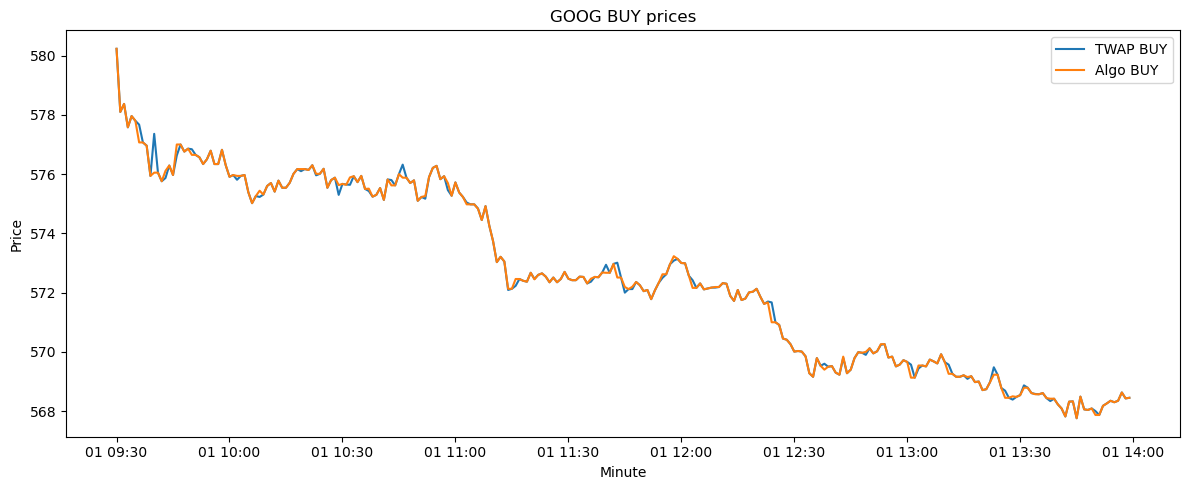

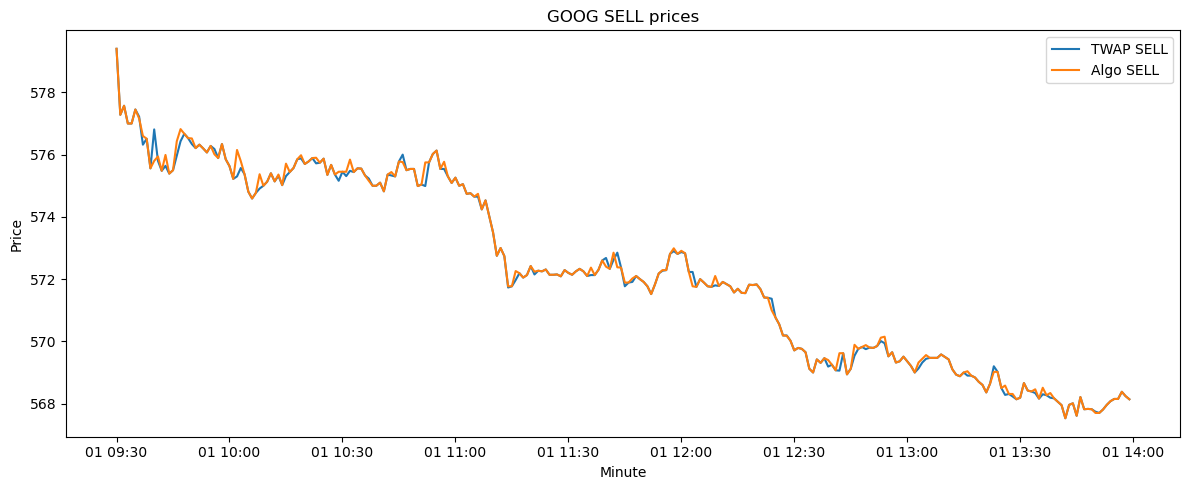

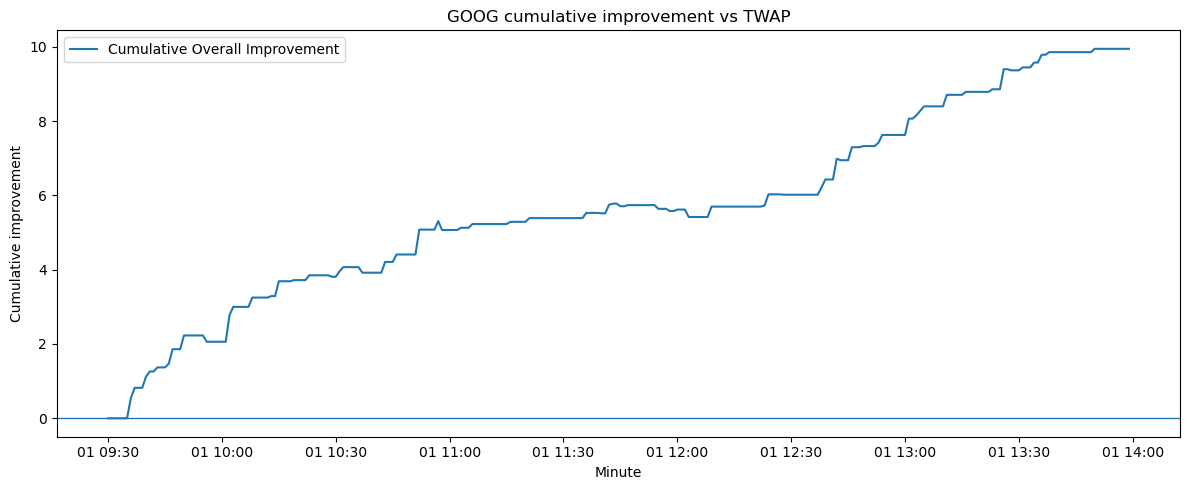

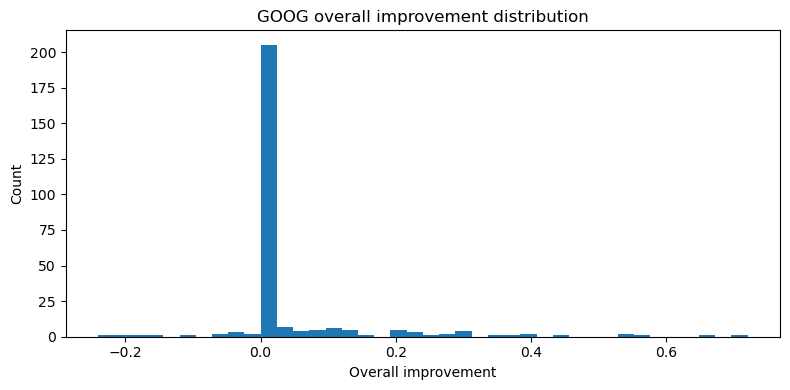

In [14]:
make_plots(result.stock, buy_log, sell_log, merged)

## 12. Save single-stock outputs


In [44]:
stock_dir = OUTPUT_DIR / result.stock
stock_dir.mkdir(parents=True, exist_ok=True)

result.execution_log.to_csv(stock_dir / f"{result.stock}_minute_execution_log.csv", index=False)
result.summary.to_csv(stock_dir / f"{result.stock}_summary_metrics.csv", index=False)

print("Saved files to:", stock_dir.resolve())
result.execution_log.head()

Saved files to: /Users/wangyiling/Desktop/ORIE5259/project/results/GOOG


,Minute,TWAP_BUY_Price,Algo_BUY_Price,BUY_Improvement,AlgoReason_BUY,TWAP_SELL_Price,Algo_SELL_Price,SELL_Improvement,AlgoReason_SELL,Overall_Improvement
0,1900-01-01 09:30:00,580.23,580.23,0.0,no_compression_first_row,579.40,579.40,0.0,no_compression_first_row,0.0
1,1900-01-01 09:31:00,578.10,578.10,0.0,no_compression_first_row,577.28,577.28,0.0,no_compression_first_row,0.0
2,1900-01-01 09:32:00,578.37,578.37,0.0,no_compression_first_row,577.57,577.57,0.0,no_compression_first_row,0.0
3,1900-01-01 09:33:00,577.58,577.58,0.0,no_compression_first_row,577.00,577.00,0.0,no_compression_first_row,0.0
4,1900-01-01 09:34:00,577.96,577.96,0.0,no_compression_first_row,577.00,577.00,0.0,no_compression_first_row,0.0


## Multi-stock comparison

Run this cell to evaluate all four train files and plot the buy/sell improvements.

This version uses:
- the same buy-side rule for all stocks
- the same event-driven sell-side structure for all stocks
- a timed sell delay after upward breakout, refined by imbalance, microprice, momentum, and spread


,Stock,Buy Improvement,Sell Improvement,Overall Improvement
0,AMZN,0.008630,0.015741,0.024370
1,GOOG,0.010000,0.026852,0.036852
2,INTC,0.000630,0.002481,0.003111
3,MSFT,0.001111,0.002481,0.003593


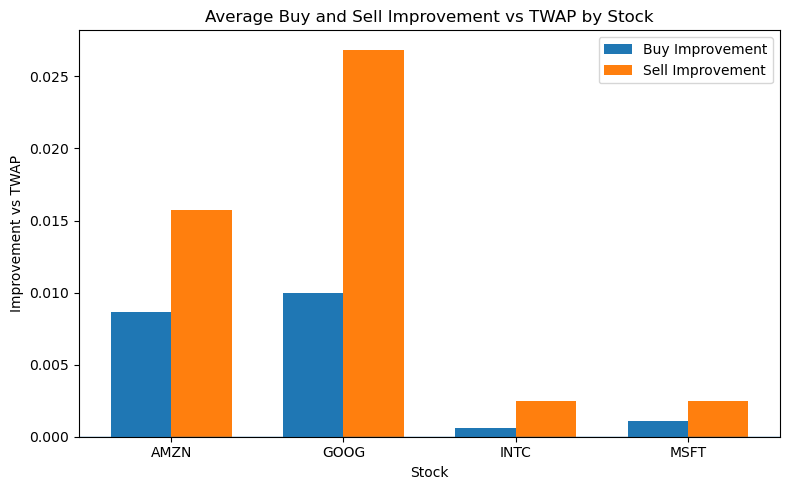

In [15]:
# Multi-stock evaluation on the train files and grouped bar plot.
# This cell runs the backtest separately for each available stock file,
# extracts the summary metrics from each result, and plots buy/sell improvement by stock.

candidate_symbols = ["AMZN", "GOOG", "INTC", "MSFT"]
stock_paths = [DATA_DIR / f"{s}_5levels_train.csv" for s in candidate_symbols]
stock_paths = [p for p in stock_paths if p.exists()]

if not stock_paths:
    raise FileNotFoundError(
        f"No *_5levels_train.csv files were found in {DATA_DIR.resolve()}. "
        "Check DATA_DIR and your file names."
    )

rows = []

for p in stock_paths:
    result_i, raw_i, feat_i, buy_i, sell_i, merged_i = run_backtest_for_file(p)
    summary_i = result_i.summary.set_index("Metric")["Value"]

    rows.append(
        {
            "Stock": result_i.stock,
            "Buy Improvement": float(summary_i["Average BUY Improvement"]),
            "Sell Improvement": float(summary_i["Average SELL Improvement"]),
            "Overall Improvement": float(summary_i["Average Overall Improvement"]),
        }
    )

multi_stock_results = pd.DataFrame(rows).sort_values("Stock").reset_index(drop=True)
display(multi_stock_results)

# Grouped bar plot
x = np.arange(len(multi_stock_results))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, multi_stock_results["Buy Improvement"], width, label="Buy Improvement")
plt.bar(x + width / 2, multi_stock_results["Sell Improvement"], width, label="Sell Improvement")
plt.axhline(0, linewidth=1)
plt.xlabel("Stock")
plt.ylabel("Improvement vs TWAP")
plt.title("Average Buy and Sell Improvement vs TWAP by Stock")
plt.xticks(x, multi_stock_results["Stock"])
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
buy_rows = []
sell_rows = []

for p in stock_paths:
    result_i, raw_i, feat_i, buy_i, sell_i, merged_i = run_backtest_for_file(p)
    stock_name = result_i.stock

    # BUY
    if buy_i is not None and len(buy_i) > 0:
        cum_imp = buy_i["Improvement"].sum()
        avg_imp = cum_imp / len(buy_i)

        buy_rows.append({
            "stock_name": stock_name,
            "average_price_improvement": float(avg_imp)
        })
    print(len(buy_i))
    # SELL
    if sell_i is not None and len(sell_i) > 0:
        cum_imp = sell_i["Improvement"].sum()
        avg_imp = cum_imp / len(sell_i)

        sell_rows.append({
            "stock_name": stock_name,
            "average_price_improvement": float(avg_imp)
        })
    print(len(sell_i))

buy_execution_df = pd.DataFrame(buy_rows)
sell_execution_df = pd.DataFrame(sell_rows)

buy_execution_df.to_csv("strategy3_buy_execution.csv", index=False)
sell_execution_df.to_csv("strategy3_sell_execution.csv", index=False)

print("Saved strategy3_buy_execution.csv")
print("Saved strategy3_sell_execution.csv")
display(buy_execution_df)
display(sell_execution_df)

270
270
270
270
270
270
270
270
Saved strategy3_buy_execution.csv
Saved strategy3_sell_execution.csv


,stock_name,average_price_improvement
0,AMZN,0.008630
1,GOOG,0.010000
2,INTC,0.000630
3,MSFT,0.001111


,stock_name,average_price_improvement
0,AMZN,0.015741
1,GOOG,0.026852
2,INTC,0.002481
3,MSFT,0.002481
